# Nhiệm vụ: Phân tích hợp đồng (Xem xét rủi ro từ các gói vay có điều khoản và mục đích khác nhau).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [2]:
df = pd.read_csv('../data/Loan_Default.csv')
sns.set_theme(style='whitegrid')

In [3]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## Phân bổ tình trạng vỡ nợ theo thời hạn khoản vay (term)

,Thời hạn khoản vay (tháng),Số lượng hồ sơ
0,96,194
1,108,33
2,120,510
3,132,93
4,144,263
5,156,174
6,165,1
7,168,82
8,180,12981
9,192,17


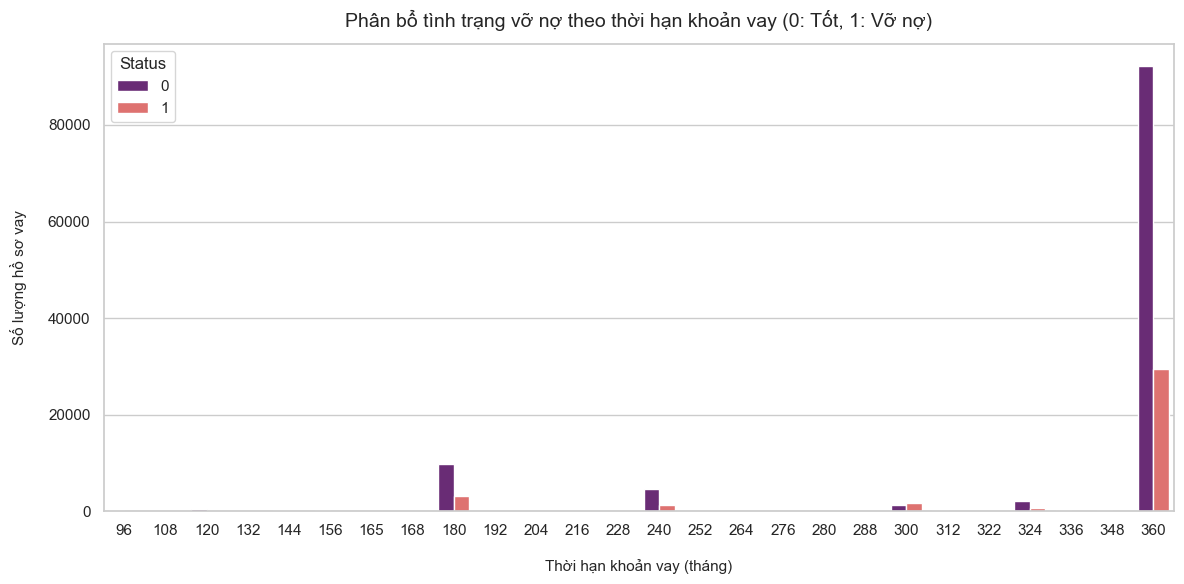

In [22]:
df_term = df.dropna(subset=['term']).copy()
df_term['term'] = df_term['term'].astype(int)

term_counts = df_term['term'].value_counts().sort_index().reset_index()
term_counts.columns = ['Thời hạn khoản vay (tháng)', 'Số lượng hồ sơ']

display(term_counts)

term_order = sorted(df_term['term'].unique())

plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df_term,
    x='term',
    hue='Status',
    order=term_order,
    width=0.75,
    palette='magma'
)

ax.set_title("Phân bổ tình trạng vỡ nợ theo thời hạn khoản vay (0: Tốt, 1: Vỡ nợ)", fontsize=14, pad=12)
ax.set_xlabel("Thời hạn khoản vay (tháng)", fontsize=11, labelpad=15)
ax.set_ylabel("Số lượng hồ sơ vay", fontsize=11, labelpad=15)

plt.tight_layout()
plt.show()

### Insight

- Khoản vay **360 tháng (30 năm)** chiếm tỷ trọng lớn nhất với **121,685 hồ sơ**, tương đương khoảng **82% tổng số khoản vay**. Các mốc thời hạn khác như **180 tháng (12,981 hồ sơ)** và **240 tháng (5,859 hồ sơ)** có số lượng thấp hơn đáng kể, các khoản vay **300 tháng** và **324 tháng** cũng xuất hiện nhưng chiếm tỷ trọng tương đối nhỏ.

- Về tỷ lệ vỡ nợ, các khoản vay dài hạn có xu hướng rủi ro cao hơn so với một số khoản vay ngắn hạn. Cụ thể:
  - **180 tháng:** tỷ lệ vỡ nợ khoảng **24.30%**
  - **240 tháng:** khoảng **20.82%**
  - **300 tháng:** khoảng **56.56%**
  - **324 tháng:** khoảng **25.42%**
  - **360 tháng:** khoảng **24.21%**

- Đáng chú ý, nhóm **300 tháng** có tỷ lệ vỡ nợ **cao vượt trội (56.56%)** so với các nhóm còn lại, mặc dù số lượng hồ sơ của nhóm này tương đối nhỏ.

- Kết quả cho thấy các khoản vay có thời hạn từ **180–360 tháng** đều có tỷ lệ vỡ nợ ở mức đáng kể. Thời gian vay kéo dài có thể làm tăng khả năng chịu tác động của các yếu tố kinh tế như biến động thu nhập, lãi suất hoặc điều kiện thị trường.

- Do đó, biến **term** có ý nghĩa trong việc phản ánh mức độ rủi ro của khoản vay và có thể đóng vai trò quan trọng trong mô hình dự đoán nợ xấu.

## Phân bổ tỷ lệ vỡ nợ theo mục đích vay (loan_purpose)

,Không vỡ nợ,Vỡ nợ
loan_purpose,,
p1,25594,8935
p2,2191,1083
p3,41938,13996
p4,42209,12590


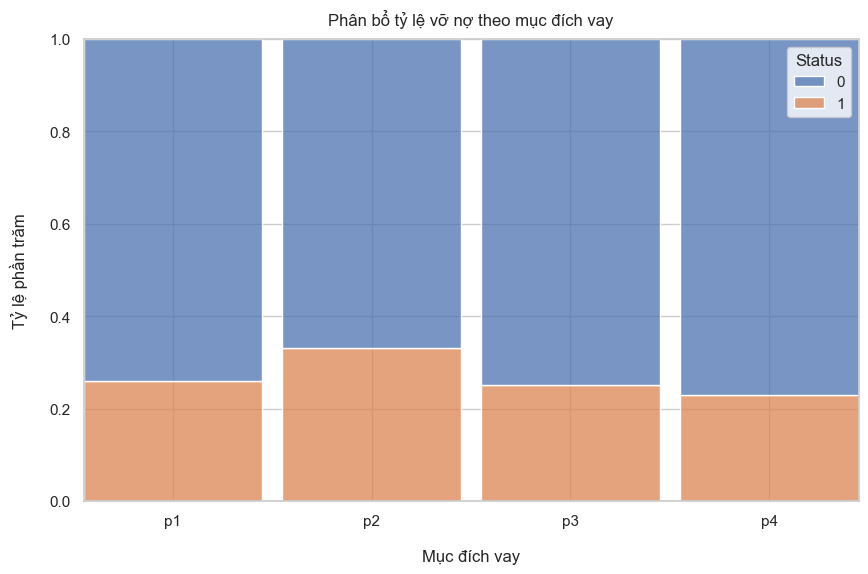

In [23]:
purpose_counts = df.groupby(['loan_purpose','Status']).size().unstack(fill_value=0)
purpose_counts.columns = ['Không vỡ nợ','Vỡ nợ']

display(purpose_counts)

purpose_order = ['p1','p2','p3','p4']

df['loan_purpose'] = pd.Categorical(
    df['loan_purpose'],
    categories=purpose_order,
    ordered=True
)

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='loan_purpose',
    hue='Status',
    multiple='fill',
    shrink=0.9,
    hue_order=[0,1],
    discrete=True
)

plt.title("Phân bổ tỷ lệ vỡ nợ theo mục đích vay", pad=10)
plt.xlabel("Mục đích vay", labelpad=15)
plt.ylabel("Tỷ lệ phần trăm", labelpad=15)

plt.show()


### Insight

- Xét về quy mô khoản vay, hai mục đích vay phổ biến nhất là **p3 (55,934 hồ sơ)** và **p4 (54,799 hồ sơ)**, chiếm phần lớn tổng danh mục cho vay. Trong khi đó, **p2 chỉ có 3,274 hồ sơ**, thấp hơn đáng kể so với các nhóm còn lại.

- Tuy nhiên, xét về **tỷ lệ vỡ nợ** (màu cam), nhóm **p2** ghi nhận mức rủi ro cao nhất với khoảng **33.1%**, cao hơn so với:
  - **p1:** khoảng **25.9%**
  - **p3:** khoảng **25.0%**
  - **p4:** khoảng **23.0%**

- Như vậy, mặc dù số lượng khoản vay của nhóm **p2** tương đối nhỏ, nhưng tỷ lệ vỡ nợ lại cao hơn khoảng **8–10%** so với một số mục đích vay khác.

- Kết quả này cho thấy **loan_purpose** có khả năng phản ánh sự khác biệt về mức độ rủi ro tín dụng giữa các nhóm khách hàng dựa trên mục đích sử dụng vốn.


## So sánh rủi ro giữa khoản vay cá nhân và vay kinh doanh (business_or_commercial)

,Tổng số hồ sơ,Tỷ lệ vỡ nợ
business_or_commercial,,
b/c,20762,0.345439
nob/c,127908,0.230377


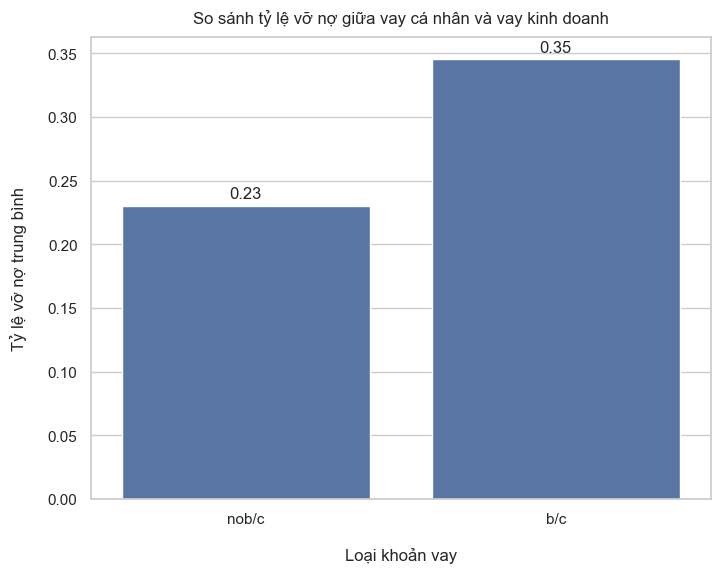

In [24]:
loan_type_counts = df.groupby('business_or_commercial')['Status'].agg(['count','mean'])
loan_type_counts.columns = ['Tổng số hồ sơ','Tỷ lệ vỡ nợ']

display(loan_type_counts)

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=df,
    x='business_or_commercial',
    y='Status',
    errorbar=None
)

ax.set_title("So sánh tỷ lệ vỡ nợ giữa vay cá nhân và vay kinh doanh", pad=10)
ax.set_xlabel("Loại khoản vay", labelpad=15)
ax.set_ylabel("Tỷ lệ vỡ nợ trung bình", labelpad=15)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.show()

### Insight

- Các khoản vay **cá nhân/tiêu dùng (nob/c)** chiếm phần lớn với **127,908 hồ sơ**, trong khi **khoản vay phục vụ kinh doanh (b/c)** chỉ có **20,762 hồ sơ**.

- Tuy nhiên, xét về **tỷ lệ vỡ nợ**, nhóm vay phục vụ mục đích kinh doanh có mức rủi ro cao hơn đáng kể:
  - **b/c:** khoảng **34.5%**
  - **nob/c:** khoảng **23.0%**

- Chênh lệch giữa hai nhóm vào khoảng **11%**, cho thấy các khoản vay phục vụ hoạt động kinh doanh có mức độ rủi ro tín dụng cao hơn so với vay tiêu dùng cá nhân.

- Điều này có thể liên quan đến tính biến động của hoạt động kinh doanh, vốn phụ thuộc vào doanh thu và điều kiện thị trường, từ đó ảnh hưởng đến khả năng trả nợ của người vay.